In [1]:
import CSV, TimeZones, Statistics
import PyPlot as plt
using Dates, LaTeXStrings
plt.pygui(true) # sets plots to popup instead of inline

# Path to parent directory
CACO_dir = dirname(dirname(dirname(@__FILE__)))

ats_year = 2022
ft_to_m = 0.305

0.305

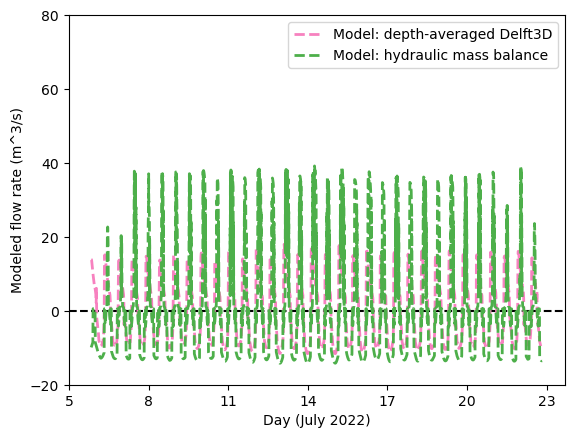

In [ ]:
using DataFrames


kb_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/hr_heb_Verified_(m)_38834_dt360s_230418.csv", DataFrame)
mh_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/Delft3D_HR_Discharge.csv", DataFrame)
GMT_to_EDT = Dates.Hour(4)
kb_model.date_time = Dates.DateTime.(kb_model.date_time, "yyyy-mm-dd HH:MM:SS") - GMT_to_EDT # Convert to EDT here!
mh_model.Datetime = Dates.DateTime.(mh_model.Datetime, "m/d/y H:M") - GMT_to_EDT # Convert to EDT
kb_model.modeltime = Dates.Time.(kb_model.date_time)
mh_model.modeltime = Dates.Time.(mh_model.Datetime)
start_time = Dates.DateTime(2022, 7, 5, 0, 0, 0) # Dates.DateTime(2022, 7, 14, 2, 0, 0)
stop_time = Dates.DateTime(2022, 7, 25, 0, 0, 0) # Dates.DateTime(2022, 7, 14, 23, 0, 0)
kb_filt = kb_model[(kb_model.date_time.>= start_time) .& (kb_model.date_time.<= stop_time), :]
mh_filt = mh_model[(mh_model.Datetime.>= start_time) .& (mh_model.Datetime.<= stop_time), :]
# IRQIV_us_time = Dates.Time.(ATS_tst_vec_us)
# IRQIV_ds_time = Dates.Time.(ATS_tst_vec_ds)

# Colorblind-friendly pallette: https://gist.github.com/thriveth/8560036

# Define x-axis tick positions in 3-hour increments
tick_interval = Dates.Day(3) # Dates.Hour(3)
tick_positions = start_time:tick_interval:stop_time
# Format tick positions as strings for x-axis labels
tick_labels = Dates.format.(tick_positions, "d") # Dates.format.(tick_positions, "HH:MM")

# Plot results
plt.close("all")
fig, ax = plt.subplots()
ax.axhline(y=0, color = "black", linestyle = "--", label="_nolegend_")
# color1 = Colors.colorant"#377eb8"
ax.plot(mh_filt.Datetime, mh_filt."Total_Discharge_m3/s", c=:"#f781bf", linewidth = 2, linestyle="--")
ax.plot(kb_filt.date_time, kb_filt.Qtotal_m3s, c=:"#4daf4a", linewidth = 2, linestyle="--")
# ax.plot(TS_op_vec_us, Q_op_vec_us_scaled, c=:"#377eb8", linewidth = 4)
# ax.plot(TS_op_vec_ds, Q_op_vec_ds, c=:"#e41a1c", linewidth = 4)
# plt.ylabel(LaTeXStrings.LaTeXString("Modeled & measured volumetric flux (m^3/s)"))
plt.ylabel(LaTeXStrings.LaTeXString("Modeled flow rate (m^3/s)"))
# plt.xlabel("Hour (July 14, 2022)")
plt.xlabel("Day (July 2022)")
plt.legend(["Model: depth-averaged Delft3D","Model: hydraulic mass balance","IR-QIV: upstream outgoing tide", "IR-QIV: downstream incoming tide"], loc = "upper right")#  )
plt.ylim([-20, 80])
plt.xticks(tick_positions, tick_labels)  # Set x-axis tick positions and labels
plt.rc("font",size=24)
plt.gcf()

In [3]:
using Interpolations

# Import thermistor data from field campaign

# ChatGPT function to find nearest thermistor times to each ATS file (for WSE)
function find_nearest_time_indices(irregular_times, regular_times)
    nearest_indices = [argmin(abs.(time .- regular_times)) for time in irregular_times]
    return nearest_indices
end

thermpath = joinpath(CACO_dir, "2022/Thermistor/P6_CACO_July_2022_truncated.txt")
therm = CSV.read(thermpath, delim = ',', DataFrame)
# # 360 lines per hour, 8640 lines per day
river_therm_cam_offset = (sqrt(9^2-2^2) + 1/3 + 7) * ft_to_m
bay_therm_cam_offset = 209/12*ft_to_m

therm[!,3] = Dates.Date.(therm[!,3], " dd u YYYY")
therm_datetime = Dates.DateTime.(therm[!,3], therm[!,4])
therm = hcat(therm, therm_datetime)
rename!(therm,[:TemperatureC, :PressureM, :Date, :Time, :DateTime])

# Find times when thermistor was deployed
therm_time_extrema = extrema(therm.DateTime)

# Import flux tower met station data for atmospheric pressure correction 
atmP_df = CSV.read(joinpath(CACO_dir, "2022/Thermistor", "2021_HRPhrag_BARO_111721_Append_2022-10-21_17-51-24-365.csv"), DataFrame, header = 70)
atmP_DateTimeUTC = Dates.DateTime.(Dates.Date.(atmP_df.Date, "mm/dd/yy") + 
    Dates.Time.(strip.(atmP_df."Time (UTC)"), "HH:MM:SS p "))
# Clean data and convert to local time zone
atmP_df.DateTimeET = Dates.DateTime.(TimeZones.astimezone.(
    TimeZones.ZonedDateTime.(atmP_DateTimeUTC, TimeZones.tz"UTC"), 
        TimeZones.tz"America/New_York")) # Convert UTC to local eastern time and remove time zone from DateTime
# Filter met station data overlapping with thermistor
atmP_df = atmP_df[findall(x -> x >= therm_time_extrema[1]-Dates.Second(10) && 
    x < therm_time_extrema[2]+Dates.Minute(13), atmP_df.DateTimeET),:] # Get data on either end of thermistor

# Interpolate met station data to thermistor frequency
atmP_seconds = Float64.((atmP_df.DateTimeET .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
atmP_interp_times = collect(therm.DateTime[1]:Dates.Second(10):therm.DateTime[end]) # Interpolate to same times as therm
atmP_interp_seconds = Float64.((atmP_interp_times .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
interp_fxn = LinearInterpolation((atmP_seconds,), atmP_df."Barometric Pressure (PSI)               ", extrapolation_bc=Flat())
atmP_interpolated = interp_fxn.(atmP_interp_seconds)

# Thermistor follows air pressure data before deployment, not so much after (out of water ind 17863)
Pcomp_inds = 169:863

PSI_to_dbar = 0.68948
# Calculate mean of pre-deployment ambient air pressure for thermistor and weather station
thermP_ambient_mean = Statistics.mean(therm.PressureM[Pcomp_inds])  # in dbar
metstation_ambient_mean = Statistics.mean(atmP_interpolated[Pcomp_inds])  # in PSI 

# Subtract met station mean pressure pre-deployment from met station time series and convert to dbar
atmP_interp_delta = (atmP_interpolated .- metstation_ambient_mean) .* PSI_to_dbar

# Change thermistor elevation relative to camera
therm_moved_datetime = Dates.DateTime(Dates.Time("08:12:00", "HH:MM:SS") + Dates.Date("2022-07-14", "yyyy-mm-dd"))
therm_moved_bool = (therm.DateTime .== therm_moved_datetime) 
therm_moved_idx = findall(x->x==1, therm_moved_bool)[]

therm.Pcorrected = therm.PressureM .- thermP_ambient_mean
therm.Pcorrected[therm_moved_idx:end] .*= (1026/1000) # Account for density of seawater on downstream side
therm.Pcorrected .-= atmP_interp_delta
thermP = therm.Pcorrected

plt.rc("font", size=14) 
plt.figure() # Plot comparison of mean-subtracted thermistor air pressure with interpolated met station pressure
# plt.plot(therm.DateTime[Pcomp_inds], therm.PressureM[Pcomp_inds].-Statistics.mean(therm.PressureM[Pcomp_inds]))
# plt.plot(therm.DateTime[Pcomp_inds], atmP_interpolated[Pcomp_inds].-Statistics.mean(atmP_interpolated[Pcomp_inds]))
# plt.scatter(atmP_interpolated[Pcomp_inds], therm.PressureM[Pcomp_inds]) # Look at time relationship between pressure readings
# plt.plot(thermP[17863:end])# Visualize thermistor data before and after deployment
# plt.plot(thermP[Pcomp_inds]) 
# plt.plot(atmP_interp_delta)
plt.plot(therm.DateTime, therm.Pcorrected)
plt.xticks(rotation=45)

thermZ = bay_therm_cam_offset.-thermP[1:therm_moved_idx] # vertical offset from camera to thermistor - 
thermZ = append!(thermZ, bay_therm_cam_offset.-thermP[therm_moved_idx+1:end])
therm = hcat(therm, thermZ)
rename!(therm, :x1 => :WaterDistanceFromCameraM)

# plt.gcf()


Row,TemperatureC,PressureM,Date,Time,DateTime,Pcorrected,WaterDistanceFromCameraM
,Float64,Float64,Date,Time,DateTime,Float64,Float64
1,25.9042,-0.049,2022-07-13,06:30:10,2022-07-13T06:30:10,-0.0128343,5.32492
2,25.9081,-0.049,2022-07-13,06:30:20,2022-07-13T06:30:20,-0.0128266,5.32491
3,25.9097,-0.049,2022-07-13,06:30:30,2022-07-13T06:30:30,-0.012819,5.3249
4,25.9091,-0.049,2022-07-13,06:30:40,2022-07-13T06:30:40,-0.0128113,5.32489
5,25.9086,-0.049,2022-07-13,06:30:50,2022-07-13T06:30:50,-0.0128036,5.32489
6,25.9086,-0.049,2022-07-13,06:31:00,2022-07-13T06:31:00,-0.012796,5.32488
7,25.9087,-0.049,2022-07-13,06:31:10,2022-07-13T06:31:10,-0.0127883,5.32487
8,25.9077,-0.049,2022-07-13,06:31:20,2022-07-13T06:31:20,-0.0127807,5.32486
9,25.9073,-0.049,2022-07-13,06:31:30,2022-07-13T06:31:30,-0.012773,5.32486


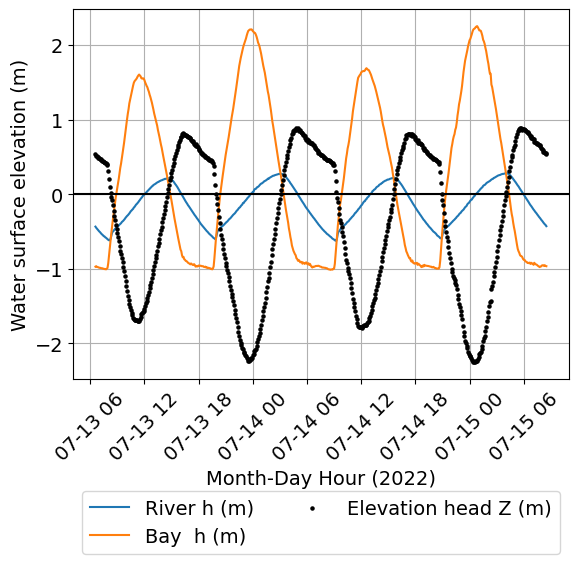

In [4]:
# Import USGS tide gauge data to relate thermistor to tide gauge
plt.close("all")

USGS_tidegauge = CSV.read(joinpath(CACO_dir, "2022/Analysis/Modeling/WL_model_inputs", "HRE_CNRD_USGS_011058798.csv"), DataFrame, header = 28)[2:end, :]

USGS_bayH = parse.(Float64, USGS_tidegauge."218558_00065") .* ft_to_m
USGS_riverH = parse.(Float64, USGS_tidegauge."66254_00065") .* ft_to_m
USGS_datetime = Dates.DateTime.(USGS_tidegauge."datetime", "m/d/y H:M")

# ATS_firstframe_time = IRQIV.ats_ts(I1images)[1]
# find_nearest_time_indices(ATS_time_extrema, USGS_datetime)

# Converting thermistor vertical offset to tide gauge

# Function to find indices of local abs(H) minima -> zero-crossings 
function local_minima_indices(vec::Vector{Float64}; threshold::Float64 = 0.2)
    absvec = abs.(vec)
    inds = [i for i in 2:length(absvec)-1 if absvec[i] < absvec[i-1] && absvec[i] < absvec[i+1] && absvec[i] < threshold]
    return inds
end

# Find overlap between tide gauge and thermistor (proxy for experiment)
therm_overlap_inds = findall(x -> x >= therm_time_extrema[1] && x <= therm_time_extrema[2], USGS_datetime)
USGS_deltaH = [USGS_datetime[therm_overlap_inds], USGS_riverH[therm_overlap_inds] .- USGS_bayH[therm_overlap_inds]]
# Deployed in river side
therm_overlap_inds_river = findall(x -> x >= therm_time_extrema[1] && x < therm_moved_datetime, USGS_datetime)
# Deployed in bay side 
therm_overlap_inds_bay = findall(x -> x > therm_moved_datetime && x <= therm_time_extrema[2], USGS_datetime)
# In subset of original indices, find local minima for river/bay side data
riverH_min_inds = therm_overlap_inds_river[local_minima_indices(USGS_riverH[therm_overlap_inds_river])]
riverH_local_mins = USGS_riverH[riverH_min_inds]
bayH_min_inds = therm_overlap_inds_bay[local_minima_indices(USGS_bayH[therm_overlap_inds_bay])]
bayH_local_mins = USGS_bayH[bayH_min_inds]

# Compare thermistor to tide gauge at multiple points immediately before camera to thermistor was measured
river_offset_times = [USGS_datetime[riverH_min_inds[4]],
    Dates.DateTime("2022-07-14T03:30:00"),
    Dates.DateTime("2022-07-14T06:30:00"),
    Dates.DateTime("2022-07-14T07:30:00"),]

river_offset_inds_USGS = findall(x -> x in river_offset_times, USGS_datetime)
river_offset_inds_therm = findall(x -> x in river_offset_times, therm.DateTime)
river_therm_gauge_offset = Statistics.mean(therm.Pcorrected[river_offset_inds_therm] .- USGS_riverH[river_offset_inds_USGS])

# On bay side, offset is around 0.9 near second peak, but shifts around first time in offset vector:
bay_offset_times = [Dates.DateTime("2022-07-15T04:05:00"),
    Dates.DateTime("2022-07-15T05:00:00"),
    Dates.DateTime("2022-07-15T06:30:00"),
    Dates.DateTime("2022-07-15T07:30:00")]
# Vertical distance from camera to thermistor measured at end on both sides according to notes, offset appears ~constant at these times
bay_offset_inds_USGS = findall(x -> x in bay_offset_times, USGS_datetime)
bay_offset_inds_therm = findall(x -> x in bay_offset_times, therm.DateTime)
bay_therm_gauge_offset = Statistics.mean(therm.Pcorrected[bay_offset_inds_therm] .- USGS_bayH[bay_offset_inds_USGS])

# Subtract gauge to therm offset from camera to thermistor distance
river_gauge_cam_offset = river_therm_cam_offset - river_therm_gauge_offset
bay_gauge_cam_offset = bay_therm_cam_offset - bay_therm_gauge_offset

# Calculate water distance from camera
river_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_river], 
    river_gauge_cam_offset .- USGS_riverH[therm_overlap_inds_river]]
bay_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_bay], 
    bay_gauge_cam_offset .- USGS_bayH[therm_overlap_inds_bay]]

inflow_time_inds = findall(x -> DateTime("2022-07-14T18:00:00") <= x <= DateTime("2022-07-14T23:59:00"), USGS_deltaH[1])
inflow_tide_inds = findall(x -> x < 0, USGS_deltaH[2][inflow_time_inds])
inflow_tide_inds = inflow_time_inds[inflow_tide_inds] # Get back into original indices 
inflow_tide_times = USGS_deltaH[1][inflow_tide_inds]

plt.figure()
plt.grid()
# plt.plot(USGS_datetime[therm_overlap_inds_river], abs.(USGS_riverH[therm_overlap_inds_river]))
# plt.plot(USGS_datetime[therm_overlap_inds_bay], abs.(USGS_bayH[therm_overlap_inds_bay]))
# plt.plot(therm.DateTime, thermP)
# plt.axvline.(USGS_datetime[riverH_min_inds])
# plt.axvline.(USGS_datetime[bayH_min_inds])
# plt.plot(therm.DateTime, therm.Pcorrected)
# plt.scatter(USGS_datetime[therm_overlap_inds_river], USGS_riverH[therm_overlap_inds_river])
# plt.scatter(USGS_datetime[therm_overlap_inds_bay], USGS_bayH[therm_overlap_inds_bay])
# plt.axvline.(river_offset_times)
# plt.axvline.(bay_offset_times)
# plt.plot(therm.DateTime, thermZ)
# plt.plot(river_gauge_dist_from_cam[1], river_gauge_dist_from_cam[2])
# plt.plot(bay_gauge_dist_from_cam[1], bay_gauge_dist_from_cam[2])
# plt.ylabel("Water surface distance from camera (m)")
# plt.legend(["Thermistor", "USGS gauge (river)", "USGS gauge (bay)"])
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_riverH[therm_overlap_inds]))
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_bayH[therm_overlap_inds]))
plt.scatter(USGS_deltaH[1], USGS_deltaH[2], color = "black", s = 5, zorder = 2)
plt.legend(["River h (m)", "Bay  h (m)", "Elevation head Z (m)"], 
    loc = "lower center", bbox_to_anchor=(0.5, -0.5), ncol=2)
plt.xlabel("Month-Day Hour (2022)")
plt.ylabel("Water surface elevation (m)")
plt.axhline(0, color = "black")
plt.xticks(rotation=45)
plt.gcf()



In [5]:
USGS_tidegauge

Row,agency_cd,site_no,datetime,tz_cd,66254_00065,66254_00065_cd,218558_00065,218558_00065_cd
,String7,String15,String15,String3,String7,String3,String7,String3
1,USGS,11058798,7/5/2022 23:00,EDT,-1.22,P,-3.09,P
2,USGS,11058798,7/5/2022 23:05,EDT,-1.27,P,-3.1,P
3,USGS,11058798,7/5/2022 23:10,EDT,-1.32,P,-3.12,P
4,USGS,11058798,7/5/2022 23:15,EDT,-1.37,P,-3.11,P
5,USGS,11058798,7/5/2022 23:20,EDT,-1.41,P,-3.13,P
6,USGS,11058798,7/5/2022 23:25,EDT,-1.46,P,-3.14,P
7,USGS,11058798,7/5/2022 23:30,EDT,-1.5,P,-3.17,P
8,USGS,11058798,7/5/2022 23:35,EDT,-1.55,P,-3.17,P
9,USGS,11058798,7/5/2022 23:40,EDT,-1.6,P,-3.18,P


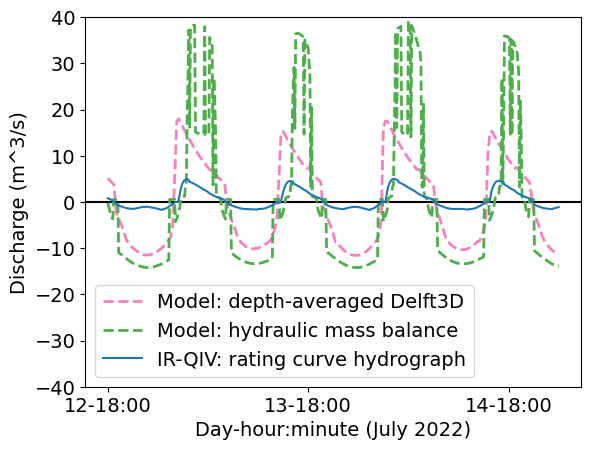

In [8]:
using Polynomials
using PyPlot  # Assuming you're using PyPlot based on plt usage

# Define polynomials
# river_rising_poly = Polynomial([-0.26539793623361047, 2.6192340898018793, - 1.6658626892074053])
# river_falling_poly = Polynomial([-0.9234834889073926, 3.4708509183225087, - 1.8033721743372466])
# Updated polynomials after AGW filter implementation:
river_rising_poly = Polynomial([-0.2872034807507623, 2.6666189718695965, - 1.5659931387023205])
river_falling_poly = Polynomial([-0.9889458308254395, 4.015230262207393, - 2.261963393392087])

bay_o1_poly = Polynomial([-0.25997538639394513, 0.09777363681119927])
bay_o2_poly = Polynomial([-0.2739713544577111, 0.14711345756388355, 0.07211584849440995])
# bay_rising_poly = Polynomial([-0.2739713544577111, 0.14711345756388355, 0.07211584849440995])
# bay_falling_poly = Polynomial([0.07266060547979399, 0.5574870296230111, 0.21164958534164496])
# Updated polynomials after AGW filter implementation:
bay_rising_poly = Polynomial([-0.2948249975986983, 0.1799879532921597, 0.0965604066817042])
bay_falling_poly = Polynomial([0.0918498971455922, 0.6351233571549071, 0.24142792052758394])

# Calculate head difference
USGS_Z = USGS_riverH .- USGS_bayH

# Define output vector
Q_ratingcurve = zeros(length(USGS_Z))

# Adjust start and end safely (must ensure indexing doesn't go out of bounds)
# start_ind = 433 # start at 2 to allow Z[ind-1] to exist, GIVE MODELS A COUPLE DAYS TO SPIN UP
start_ind = findfirst(x -> x ==DateTime(2022, 7, 12, 18, 0), USGS_datetime)
# end_ind = 288 * 14 + start_ind          # length = 4896
end_ind = findfirst(x -> x ==DateTime(2022, 7, 15, 0, 0), USGS_datetime)
n_points = end_ind - start_ind + 1

# Constants
# culvert_h = 5 * ft_to_m
culvert_h_bay = 9.75 * ft_to_m # (10'3" - 6")
culvert_h_river = 5.75 * ft_to_m # (6'3" - 6")
# culvert_top_Z = -26.1317 # in camera coords
culvert_top_Z_bay = 1.55143 # in gauge coords
culvert_bot_Z_bay = culvert_top_Z_bay - culvert_h_bay
culvert_bot_Z_river = culvert_bot_Z_bay + (1.5*ft_to_m)
culvert_top_Z_river = culvert_bot_Z_river + culvert_h_river
culvert_top_Z_inner = culvert_bot_Z_river + 5 * ft_to_m
river_culvert_width = 6*ft_to_m + (7/12)*ft_to_m + 7*ft_to_m + (2/12)*ft_to_m + 6*ft_to_m
bay_culvert_width = 6*ft_to_m #+ (7/12)*ft_to_m
vel_idx = 0.9

# Main loop
window_halfwidth = 6  # ~30 minutes

for (local_ind, Z) in enumerate(USGS_Z[start_ind:end_ind])
    global_ind = start_ind + local_ind - 1

    # Local window to evaluate rise/fall trend
    window_start = max(global_ind - window_halfwidth, 1)
    window_end   = min(global_ind + window_halfwidth, length(USGS_Z))
    Z_window = USGS_Z[window_start:window_end]

    if Z == 0
        flowrate = 0.0

    elseif Z > 0  # River side
        h = USGS_riverH[global_ind] - culvert_bot_Z_river
        A_river = h * river_culvert_width

        # Determine whether rising or falling
        is_local_max = global_ind == window_start - 1 + findmax(Z_window)[2]
        Usurf = is_local_max || global_ind > window_start - 1 + findmax(Z_window)[2] ?
                river_falling_poly(Z) : river_rising_poly(Z)

        flowrate = Usurf < 0 ? 0 : Usurf * A_river

    # else  # Z < 0 → Bay side
    #     if USGS_bayH[global_ind] >= culvert_top_Z_bay
    #         h = culvert_h_bay
    #     else
    #         h = USGS_bayH[global_ind] - culvert_bot_Z_bay
    #     end
    #     A_bay = h * bay_culvert_width

    #     is_local_min = global_ind == window_start - 1 + findmin(Z_window)[2]
    #     Usurf = is_local_min || global_ind > window_start - 1 + findmin(Z_window)[2] ?
    #             bay_falling_poly(Z) : bay_rising_poly(Z)

    #     flowrate = Usurf * A_bay
    #     if flowrate > 0
    #         flowrate = 0
    #     end
    # end
    else  # Z < 0 → Bay side
        if USGS_bayH[global_ind] >= culvert_top_Z_bay
            h = culvert_h_bay
            A_bay = h * bay_culvert_width
            Usurf = bay_rising_poly(Z)  # immediately switch to falling
        else
            h = USGS_bayH[global_ind] - culvert_bot_Z_bay
            A_bay = h * bay_culvert_width

            is_local_min = global_ind == window_start - 1 + findmin(Z_window)[2]
            Usurf = is_local_min || global_ind > window_start - 1 + findmin(Z_window)[2] ?
                    bay_falling_poly(Z) : bay_rising_poly(Z)
        end

        flowrate = Usurf * A_bay
        if flowrate > 0
            flowrate = 0
        end
    end
    Q_ratingcurve[global_ind] = flowrate * vel_idx
end


start_time = USGS_datetime[start_ind]
end_time = USGS_datetime[end_ind]

mh_start_ind = findmin(abs.(mh_filt.Datetime .- start_time))[2]
mh_end_ind   = findmin(abs.(mh_filt.Datetime .- end_time))[2]

kb_start_ind = findmin(abs.(kb_filt.date_time .- start_time))[2]
kb_end_ind   = findmin(abs.(kb_filt.date_time .- end_time))[2]

tick_interval = Dates.Hour(24) # Dates.Hour(3)
tick_positions = start_time:tick_interval:end_time
tick_labels = Dates.format.(tick_positions, "dd-HH:MM")

# Plotting
plt.figure()
plt.axhline(0, color="black", label="_nolegend_")
plt.plot(mh_filt.Datetime[mh_start_ind:mh_end_ind], mh_filt."Total_Discharge_m3/s"[mh_start_ind:mh_end_ind], c=:"#f781bf", linewidth = 2, linestyle="--")
plt.plot(kb_filt.date_time[kb_start_ind:kb_end_ind], kb_filt.Qtotal_m3s[kb_start_ind:kb_end_ind], 
    c=:"#4daf4a", linewidth = 2, linestyle="--")
plt.plot(USGS_datetime[start_ind:end_ind], Q_ratingcurve[start_ind:end_ind])
plt.legend(["Model: depth-averaged Delft3D","Model: hydraulic mass balance","IR-QIV: rating curve hydrograph"], 
    loc = "lower left")#  )
plt.ylabel("Discharge (m^3/s)")
plt.xticks(tick_positions, tick_labels)#, rotation = 45)  # Set x-axis tick positions and labels
plt.xlabel("Day-hour:minute (July 2022)")
plt.ylim([-40, 40])
# plt.axvline.(USGS_datetime[cross_inds])
plt.gcf()


In [20]:
scale_factor = 3.05

minimum(USGS_deltaH[2])/scale_factor
# Scale factor 3.05:1
# USGS_deltaH
# 8.75' from bottom of culvert roof to base of sluicegate is 2 2/3 m
2.667/scale_factor

0.8744262295081967

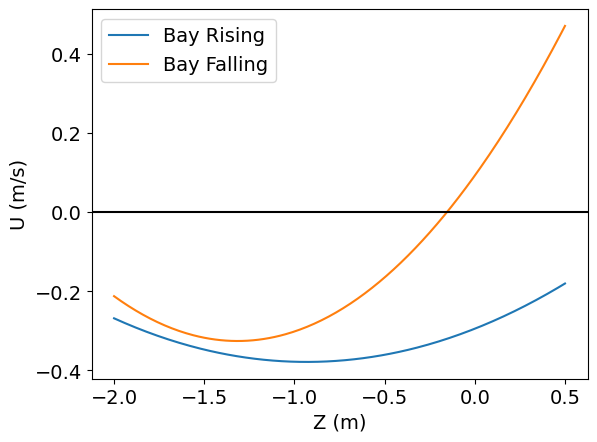

In [12]:
plt.figure()
z_vals = -2:0.01:.5
# plt.plot(z_vals, river_rising_poly.(z_vals), label="River Rising")
# plt.plot(z_vals, river_falling_poly.(z_vals), label="River Falling")
plt.plot(z_vals, bay_rising_poly.(z_vals), label="Bay Rising")
plt.plot(z_vals, bay_falling_poly.(z_vals), label="Bay Falling")
plt.axhline(0, color="black")
plt.xlabel("Z (m)")
plt.ylabel("U (m/s)")
plt.legend()
plt.gcf()


In [7]:
function align_zero_min_expand(ax_ref, ax_target, pad_frac=0.02)
    """
    Align y=0 on ax_target to ax_ref, expanding ax_target's span
    by the minimal amount needed (plus pad_frac) so no data is cut off.
    """
    # 1) Reference zero relative position
    y0r, y1r = ax_ref.get_ylim()
    rel0 = (0 - y0r) / (y1r - y0r)

    # 2) Target data extents
    dmin, dmax = ax_target.dataLim.ymin, ax_target.dataLim.ymax
    pad = pad_frac * (dmax - dmin)

    # 3) Compute required spans so data + pad fit above and below zero:
    #    below zero we need b ≤ dmin - pad  where b = -rel0*s
    #    above zero we need b + s ≥ dmax + pad  ⇒ -rel0*s + s ≥ dmax + pad
    # Solve each:
    s_req1 = (dmax + pad) / (1 - rel0)
    s_req2 = -(dmin - pad) / rel0

    # 4) Take the largest requirement, or keep original if it's already big enough
    y0t, y1t = ax_target.get_ylim()
    orig_span = y1t - y0t
    new_span = max(orig_span, s_req1, s_req2)

    # 5) Compute new bottom b so that zero is at rel0 * new_span
    new_y0 = -rel0 * new_span
    new_y1 = new_y0 + new_span

    ax_target.set_ylim(new_y0, new_y1)
    ax_ref.axhline(0, color="gray", linewidth=1)
end

align_zero_min_expand (generic function with 2 methods)

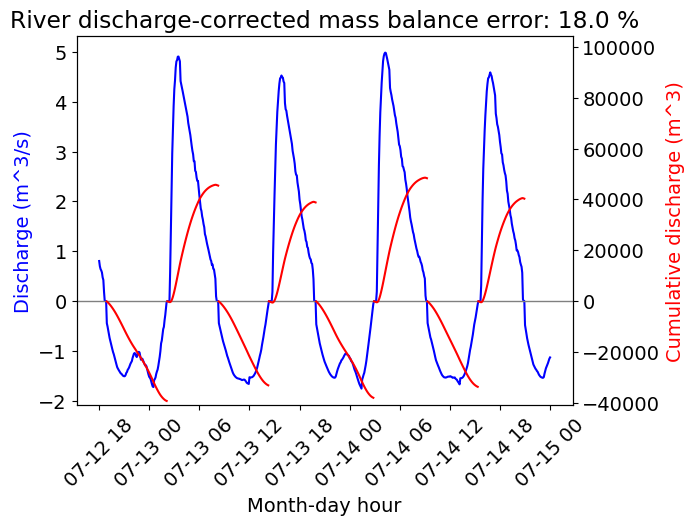

In [10]:
# Calculating mass balance

using Trapz

cross_inds = findall(diff(signbit.(Q_ratingcurve)) .!= 0)

Δt = 60*5  # seconds
in_prisms = Float64[]
out_prisms = Float64[]
HR_discharge = .34

fig, ax1 = plt.subplots()
plt.xlabel("Month-day hour")
plt.xticks(rotation=45)
ax1.plot(USGS_datetime[start_ind:end_ind], Q_ratingcurve[start_ind:end_ind], color = "blue")
ax1.set_ylabel("Discharge (m^3/s)", color = "blue")
ax2 = ax1.twinx()
# for i in 1:length(cross_inds)-1
for i in 1:length(cross_inds)-2
    start = cross_inds[i]
    stop = cross_inds[i+1]
    duration = (stop - start) * Δt

    segment = Q_ratingcurve[start:stop] .- HR_discharge
    # t_segment = collect((0:length(segment)-1)) .* Δt
    t_segment = collect(0:Δt:(length(segment)-1)*Δt)  # time vector in seconds

    # vol = sum(segment) * Δt  # simple Riemann sum (rectangle rule)
    vol = trapz(t_segment, segment)
    vol_int = [trapz(t_segment[1:i], segment[1:i]) for i in 2:length(t_segment)]

    ax2.plot(USGS_datetime[start+1:stop], vol_int, color = "red")
    
    if vol > 0
        push!(out_prisms, vol)
    else
        push!(in_prisms, -vol)
    end
end
ax2.set_ylabel("Cumulative discharge (m^3)", color = "red")
align_zero_min_expand(ax1, ax2)

n_cycles = min(length(in_prisms), length(out_prisms))
mass_balance = out_prisms[1:n_cycles] .- in_prisms[1:n_cycles]
total_duration = (cross_inds[end] - cross_inds[1]) * Δt

# plt.figure()
# plt.plot(mass_balance)
# plt.gcf()

sum(mass_balance) / total_duration # Error in flow rate

# Calculate mass balance error
MBE = abs(sum(in_prisms) - sum(out_prisms))/Statistics.mean((sum(in_prisms), sum(out_prisms))) 

# plt.axvline.()
plt.title("River discharge-corrected mass balance error: $(round(MBE*100, digits=1)) %")
plt.gcf()


In [19]:

cross_inds = findall(diff(signbit.(y)) .!= 0)
cross_inds = cross_inds[2:end]

cross_int = Float64[]
for i in 1:length(cross_inds)-1
    start = cross_inds[i]
    stop = cross_inds[i+1]
    int_val = sum(Q_ratingcurve[start:stop])
    push!(cross_int, int_val)
end

int_pair_sums = [cross_int[i] + cross_int[i+1] for i in 1:2:length(cross_int)-1]

fig, ax1 = plt.subplots()
plt.xticks(rotation=45)
plt.axvline.(USGS_datetime[cross_inds[2:2:end]], color = "black")
ax1.plot(USGS_datetime[start_ind:end_ind], Q_ratingcurve[start_ind:end_ind], color = "blue")
ax1.set_ylabel("Discharge (m^3/s)", color = "blue")
ax2 = ax1.twinx()
ax2.scatter(USGS_datetime[cross_inds[2:2:end]], int_pair_sums, color = "red")
ax2.set_ylabel("Cumulative sum (m^3)", color = "red")
plt.gcf()

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

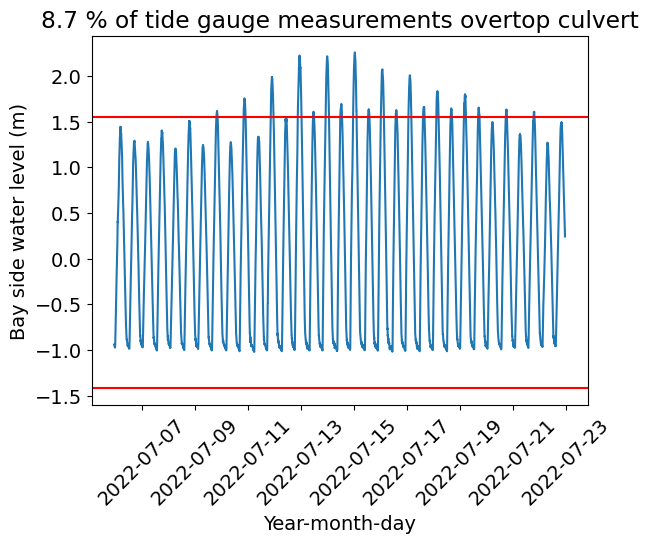

In [12]:
# Calculate percentage of tides that overtop culvert

overtop_pct = sum(x -> x > culvert_top_Z_bay, USGS_bayH) / length(USGS_bayH) * 100

plt.figure()
plt.title("$(round(overtop_pct,digits=1)) % of tide gauge measurements overtop culvert")
plt.plot(USGS_datetime, USGS_bayH)
plt.axhline(culvert_top_Z_bay, color = "red")
plt.axhline(culvert_bot_Z_bay, color = "red")
plt.ylabel("Bay side water level (m)")
plt.xlabel("Year-month-day")
plt.xticks(rotation=45)

full_gauge_record = CSV.read(joinpath(CACO_dir, "2022/Analysis/Modeling/WL_model_inputs", "USGS_gauge_data_completerecord.csv"), DataFrame, header = 28)[2:end, :]

# parse.(Float64, filter(x -> x != "missing", full_gauge_record."218558_00065"))
bay_gauge_complete = parse.(Float64, skipmissing(full_gauge_record."218558_00065")) .* ft_to_m
(length(full_gauge_record."218558_00065") - length(bay_gauge_complete)) / length(full_gauge_record."218558_00065") # 12% of data missing for ocean gauge

overtop_pct_full = sum(x -> x > culvert_top_Z_bay, bay_gauge_complete) / length(bay_gauge_complete) * 100

plt.gcf()


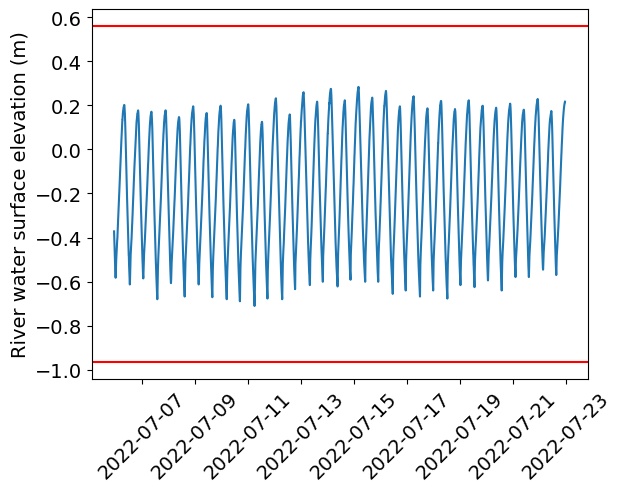

In [19]:
plt.figure()
plt.plot(USGS_datetime, USGS_riverH)
# plt.axhline(culvert_top_Z_bay)
# plt.axhline(culvert_bot_Z_bay)
plt.axhline(culvert_bot_Z_river, color = "red")
# plt.axhline(culvert_top_Z_river, color = "red")
plt.axhline(culvert_top_Z_inner, color = "red")
# plt.legend(["Bay roof", "Bay floor", "River roof", "Inner floor"])
plt.xticks(rotation=45)
plt.ylabel("River water surface elevation (m)")
plt.gcf()